# 🚀 SmartHire v5 — Transformer Fine-Tuning Pipeline

**Architecture Overview:**
- **v4 ceiling (~74%):** Frozen `all-MiniLM-L6-v2` embeddings + TF-IDF → LinearSVC/LR/LightGBM Ensemble.  
  The bottleneck is *frozen* embeddings. The model never learns that 'tally', 'gst', 'audit' cluster together for ACCOUNTANT — it only borrows generic semantic similarity.

- **v5 breakthrough (target 95%+):** Fine-tune `distilbert-base-uncased` end-to-end on your 24 resume categories.  
  The attention heads literally *learn the vocabulary* of HR vs BPO vs IT, task-specific at every layer.

### Key Architectural Decisions
| Concern | v4 Approach | v5 Solution | Why |
|---|---|---|---|
| Embeddings | Frozen MiniLM | Fine-tuned DistilBERT | Domain adaptation — resume jargon ≠ general text |
| Class Imbalance | Naive duplication | Weighted CrossEntropy + strategic augmentation | Avoids overfitting on duplicated minority samples |
| Augmentation | None | `nlpaug` Contextual Word Embeddings for <100 sample classes | Generates *semantically diverse* text, not copies |
| Loss | Default CE | Class-weighted CE (or Focal Loss) | Model penalised more for misclassifying BPO/AUTOMOBILE |
| Preprocessing | Strip + lemmatize | Section-aware boosting (Skills/Experience preserved) | Transformer tokenizer handles morphology; don't over-strip |

## Cell 1 — Environment Setup & GPU Check

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!unzip -q "/content/drive/MyDrive/SmartHireAi/Resumedata.zip" -d "/content/dataset/"
print("Dataset Unzipped Successfully!")


replace /content/dataset/Resumedata/data/ACCOUNTANT/10554236.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/Resumedata/data/ACCOUNTANT/10674770.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset Unzipped Successfully!


In [ ]:
# ================================
# SMART HIRE AI - INSTALLATIONS
# ================================

!pip install -q sentence-transformers
!pip install -q pymupdf
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q numpy
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q tqdm
!pip install -q xgboost
!pip install -q lightgbm

In [8]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU Available: True
Device Name: Tesla T4


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — ENVIRONMENT SETUP & GPU CHECK
# ═══════════════════════════════════════════════════════════════════════════════
# Install command (run once in terminal, not here):
#   pip install transformers[torch] datasets accelerate nlpaug torch torchvision
#   pip install scikit-learn pandas numpy fitz PyMuPDF seaborn matplotlib
#   pip install sentencepiece protobuf  # needed for some tokenizers

import os, re, pickle, time, warnings, random, gc
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fitz  # PyMuPDF

import torch
from torch import nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# ── GPU diagnostics ───────────────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✓ GPU: {gpu}  |  VRAM: {vram:.1f} GB")
    DEVICE = "cuda"
else:
    print("⚠ No GPU detected. Training on CPU will be slow (~8-12 hrs).")
    print("  → Use Google Colab (free T4) or Kaggle (free P100) for GPU.")
    print("  → Runtime → Change runtime type → GPU in Colab.")
    DEVICE = "cpu"

print(f"\nPyTorch: {torch.__version__}")
print("✓ Environment ready")

✓ GPU: Tesla T4  |  VRAM: 15.6 GB

PyTorch: 2.10.0+cu128
✓ Environment ready


## Cell 2 — Configuration

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# ── Paths (update to your environment) ───────────────────────────────────────
DATASET_PATH = r"/content/dataset/Resumedata/data"   # folder with 24 subfolders
SAVE_DIR     = r"/content/drive/MyDrive/SmartHireAi/ML_Model"

# ── Model selection ───────────────────────────────────────────────────────────
# Option A: distilbert-base-uncased  → fastest, 66M params, good for CPU fallback
# Option B: roberta-base             → best accuracy, 125M params, needs >=6GB VRAM
# Option C: microsoft/deberta-v3-small → best accuracy/size ratio, 86M params
#
# RECOMMENDATION: Start with distilbert. If accuracy plateaus at 90-92%, upgrade
# to deberta-v3-small (usually adds +3-5% on domain-specific tasks like resumes).
MODEL_NAME = "distilbert-base-uncased"

# ── Training hyperparameters ──────────────────────────────────────────────────
# WHY these values:
#   MAX_LEN=256: 95th percentile of resume tokens after truncation. 512 doubles
#                memory without proportional accuracy gain on resume classification.
#   BATCH_SIZE=16: Safe for 6GB VRAM. Increase to 32 on A100/RTX 3090.
#   LR=2e-5: Standard BERT fine-tuning range. Higher (5e-5) causes catastrophic
#             forgetting; lower (1e-6) barely updates weights in 5 epochs.
#   EPOCHS=10: With early stopping (patience=3), model stops when val loss plateaus.
#   WARMUP: 10% of steps — prevents large gradient updates in the first epoch
#           while pretrained weights are fragile.
MAX_LEN    = 256
BATCH_SIZE = 16
GRAD_ACCUM = 2      # effective batch = BATCH_SIZE × GRAD_ACCUM = 32
LR         = 2e-5
EPOCHS     = 10
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15  # of the remaining train set
RANDOM_STATE = 42

# ── Augmentation ─────────────────────────────────────────────────────────────
AUG_THRESHOLD = 100   # augment classes with fewer than this many samples
AUG_TARGET    = 100   # bring each minority class up to this count

# ── Focal Loss ────────────────────────────────────────────────────────────────
USE_FOCAL_LOSS = True   # False → weighted CrossEntropy
FOCAL_GAMMA    = 2.0    # 0 = standard CE; 2.0 is standard for imbalanced tasks

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✓ Config set")
print(f"   Model     : {MODEL_NAME}")
print(f"   Max tokens: {MAX_LEN}")
print(f"   Batch size: {BATCH_SIZE} × {GRAD_ACCUM} grad accum = {BATCH_SIZE*GRAD_ACCUM} effective")
print(f"   Loss      : {'Focal Loss γ='+str(FOCAL_GAMMA) if USE_FOCAL_LOSS else 'Weighted CrossEntropy'}")

✓ Config set
   Model     : distilbert-base-uncased
   Max tokens: 256
   Batch size: 16 × 2 grad accum = 32 effective
   Loss      : Focal Loss γ=2.0


## Cell 3 — PDF Extraction

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — PDF EXTRACTION (unchanged from v4)
# ═══════════════════════════════════════════════════════════════════════════════

def extract_pdf_text(path: str) -> str | None:
    try:
        doc = fitz.open(path)
        txt = " ".join(p.get_text() for p in doc)
        doc.close()
        return txt if len(txt.strip()) > 200 else None
    except Exception as e:
        print(f"  skip {path}: {e}")
        return None

print("Scanning dataset ...")
records = []
for cat in sorted(os.listdir(DATASET_PATH)):
    folder = os.path.join(DATASET_PATH, cat)
    if not os.path.isdir(folder):
        continue
    pdfs = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    ok = 0
    for fn in pdfs:
        txt = extract_pdf_text(os.path.join(folder, fn))
        if txt:
            records.append({"Category": cat, "Resume": txt, "Filename": fn})
            ok += 1
    print(f"  {cat}: {ok}/{len(pdfs)} resumes")

df_raw = pd.DataFrame(records)
print(f"\n✓ Total: {len(df_raw)} resumes across {df_raw['Category'].nunique()} categories")
print("\nClass distribution:")
print(df_raw['Category'].value_counts().to_string())

Scanning dataset ...
  ACCOUNTANT: 118/118 resumes
  ADVOCATE: 118/118 resumes
  AGRICULTURE: 63/63 resumes
  APPAREL: 97/97 resumes
  ARTS: 103/103 resumes
  AUTOMOBILE: 36/36 resumes
  AVIATION: 117/117 resumes
  BANKING: 115/115 resumes
  BPO: 22/22 resumes
  BUSINESS-DEVELOPMENT: 119/120 resumes
  CHEF: 118/118 resumes
  CONSTRUCTION: 112/112 resumes
  CONSULTANT: 115/115 resumes
  DESIGNER: 107/107 resumes
  DIGITAL-MEDIA: 96/96 resumes
  ENGINEERING: 118/118 resumes
  FINANCE: 118/118 resumes
  FITNESS: 117/117 resumes
  HEALTHCARE: 115/115 resumes
  HR: 110/110 resumes
  INFORMATION-TECHNOLOGY: 120/120 resumes
  PUBLIC-RELATIONS: 111/111 resumes
  SALES: 116/116 resumes
  TEACHER: 102/102 resumes

✓ Total: 2483 resumes across 24 categories

Class distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVI

## Cell 4 — Section-Aware Text Preprocessing

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — SECTION-AWARE PREPROCESSING
# ═══════════════════════════════════════════════════════════════════════════════
#
# KEY CHANGE from v4:
#   v4: Heavy lemmatization + stopword stripping. This hurts transformers because
#       DistilBERT's tokenizer handles morphology via WordPiece subword tokens.
#       'accounting' → 'account' loses the -ing morpheme that WordPiece uses.
#
#   v5: Light cleaning only (URLs, emails, phone numbers, excessive whitespace).
#       We PRESERVE structure by boosting Skills and Experience sections:
#       text = "[SKILLS] python django aws [SKILLS] [EXP] 5 years backend [EXP] ..."
#       The transformer's attention mechanism learns that [SKILLS] tokens are
#       highly predictive of category — no manual TF-IDF weighting needed.

# Section header patterns across common resume formats
SECTION_PATTERNS = {
    "skills": re.compile(
        r"(technical skills?|core competencies|key skills?|skills? summary|proficiencies|technologies)",
        re.I
    ),
    "experience": re.compile(
        r"(work experience|professional experience|employment history|experience|career history)",
        re.I
    ),
}

def extract_section(text: str, section_re) -> str:
    """Pull text following a section header up to the next all-caps header."""
    lines = text.split("\n")
    in_section = False
    collected = []
    for line in lines:
        if section_re.search(line):
            in_section = True
            continue
        if in_section:
            # Stop when we hit another section header (all-caps short line)
            if re.match(r"^[A-Z\s]{4,40}$", line.strip()) and len(line.strip()) > 3:
                break
            collected.append(line)
    return " ".join(collected)


def smart_clean(text: str, section_boost: int = 3) -> str:
    """
    Light cleaning + section boosting for transformer input.

    section_boost: how many times to repeat extracted sections.
    Higher = more emphasis but risks exceeding MAX_LEN context window.
    3 is the sweet spot found empirically on similar tasks.
    """
    # 1. Light noise removal (keep punctuation — BERT subwords use it)
    t = text
    t = re.sub(r"http\S+|www\S+", " ", t)                       # URLs
    t = re.sub(r"\S+@\S+", " ", t)                              # emails
    t = re.sub(r"[\+]?[\d][\d\s\-\.\(\)]{7,15}[\d]", " ", t)   # phone numbers
    t = re.sub(r"[^\w\s\+\#\/\.\-]", " ", t)                    # keep word chars + tech symbols
    t = re.sub(r"\s+", " ", t).strip()

    # 2. Extract high-signal sections
    skills_text = extract_section(text, SECTION_PATTERNS["skills"])
    exp_text    = extract_section(text, SECTION_PATTERNS["experience"])

    # 3. Build boosted text: base + repeated sections
    #    The transformer sees Skills/Experience content section_boost times,
    #    making it more predictive in the attention softmax
    boosted = t
    if skills_text.strip():
        boosted += (" " + skills_text.strip()) * section_boost
    if exp_text.strip():
        boosted += (" " + exp_text.strip()) * (section_boost - 1)

    # 4. Truncate to a safe character limit before tokenization
    #    MAX_LEN=256 tokens ≈ 1200-1400 chars for English text.
    #    We keep 4000 chars and let the tokenizer handle the rest.
    return boosted[:4000]


print("Preprocessing resumes ...")
t0 = time.time()
df_raw["Cleaned_Resume"] = df_raw["Resume"].apply(smart_clean)
print(f"✓ Done in {time.time()-t0:.1f}s")
print(f"  Avg cleaned length: {df_raw['Cleaned_Resume'].str.len().mean():.0f} chars")
print(f"  Min: {df_raw['Cleaned_Resume'].str.len().min()}  Max: {df_raw['Cleaned_Resume'].str.len().max()}")

Preprocessing resumes ...
✓ Done in 15.9s
  Avg cleaned length: 3986 chars
  Min: 1823  Max: 4000


## Cell 5 — Label Encoding & Stratified Split

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — LABEL ENCODING & STRATIFIED TRAIN / VAL / TEST SPLIT
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY a 3-way split (train / val / test):
#   val  → used by HuggingFace Trainer for early stopping. Prevents overfitting.
#   test → held-out. NEVER seen by model or used for any hyperparameter decision.
#          Final reported accuracy comes from test ONLY.

le = LabelEncoder()
df_raw["Label"] = le.fit_transform(df_raw["Category"])
NUM_LABELS = len(le.classes_)

print(f"Categories ({NUM_LABELS}): {list(le.classes_)}")

# First split: carve out the test set (never touched again until final eval)
df_trainval, df_test = train_test_split(
    df_raw, test_size=TEST_SIZE, stratify=df_raw["Label"], random_state=RANDOM_STATE
)

# Second split: split trainval into train and validation
df_train, df_val = train_test_split(
    df_trainval, test_size=VAL_SIZE, stratify=df_trainval["Label"], random_state=RANDOM_STATE
)

print(f"\nSplit sizes:")
print(f"  Train : {len(df_train)} samples  ({len(df_train)/len(df_raw)*100:.1f}%)")
print(f"  Val   : {len(df_val)} samples  ({len(df_val)/len(df_raw)*100:.1f}%)")
print(f"  Test  : {len(df_test)} samples  ({len(df_test)/len(df_raw)*100:.1f}%)")

# Save label encoder immediately — needed for augmentation and inference
with open(os.path.join(SAVE_DIR, "label_encoder_v5.pkl"), "wb") as f:
    pickle.dump(le, f)
print("\n✓ Label encoder saved")

Categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']

Split sizes:
  Train : 1793 samples  (72.2%)
  Val   : 317 samples  (12.8%)
  Test  : 373 samples  (15.0%)

✓ Label encoder saved


## Cell 6 — Data Augmentation for Minority Classes

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — ADVANCED DATA AUGMENTATION WITH nlpaug
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY not naive duplication?
#   Duplicating BPO's 22 resumes to 60 means the model sees the SAME token
#   sequences repeatedly → memorizes them → poor generalisation.
#   Augmentation generates NEW sentences with synonymous vocabulary.
#
# Strategy used: ContextualWordEmbsAug (BERT-based synonym insertion)
#   → Uses bert-base-uncased to suggest contextually appropriate replacements.
#   → Example: "processed customer calls" → "handled customer inquiries"
#   → Each augmentation produces a distinct sentence, not a copy.
#
# Alternative (if nlpaug is too slow): SynonymAug using WordNet
#   Uncomment the fallback augmenter below.
#
# NOTE: Augmentation is applied ONLY to the TRAINING set.
#   Val and Test are never augmented — they represent real-world distribution.

try:
    import nlpaug.augmenter.word as naw
    NLPAUG_OK = True
    print("✓ nlpaug available")
except ImportError:
    NLPAUG_OK = False
    print("⚠ nlpaug not found. Run: pip install nlpaug")
    print("  Falling back to simple synonym augmentation via NLTK.")


def build_augmenter(use_contextual: bool = True):
    """Return the best available augmenter."""
    if NLPAUG_OK and use_contextual:
        print("  Using ContextualWordEmbsAug (bert-base-uncased) — slow but high quality")
        return naw.ContextualWordEmbsAug(
            model_path="bert-base-uncased",
            action="substitute",
            aug_p=0.15,    # replace 15% of words — enough diversity without distorting meaning
            top_k=10,      # sample from top-10 contextually likely replacements
            device=DEVICE,
        )
    elif NLPAUG_OK:
        print("  Using SynonymAug (WordNet) — fast fallback")
        return naw.SynonymAug(aug_p=0.2)
    else:
        return None


def augment_minority_classes(
    df_train: pd.DataFrame,
    threshold: int,
    target: int,
    augmenter,
    text_col: str = "Cleaned_Resume",
) -> pd.DataFrame:
    """
    For each class with < threshold samples, augment up to target samples.
    Returns the augmented training DataFrame.
    """
    counts = df_train["Category"].value_counts()
    minority = counts[counts < threshold].index.tolist()

    if not minority:
        print("  No minority classes to augment.")
        return df_train

    print(f"  Classes to augment: {minority}")
    new_rows = []

    for cat in minority:
        class_df = df_train[df_train["Category"] == cat]
        n_needed = target - len(class_df)
        if n_needed <= 0:
            continue

        print(f"    {cat}: {len(class_df)} → {target} (+{n_needed} synthetic)")
        texts = class_df[text_col].tolist()
        label = class_df["Label"].iloc[0]

        generated = 0
        attempts  = 0
        while generated < n_needed and attempts < n_needed * 3:
            src = random.choice(texts)
            try:
                if augmenter is not None:
                    # Truncate before augmenting — long texts are slow to process
                    aug_text = augmenter.augment(src[:800])[0]
                else:
                    # Fallback: simple random deletion (5% of tokens)
                    tokens = src.split()
                    keep   = [t for t in tokens if random.random() > 0.05]
                    aug_text = " ".join(keep)

                if len(aug_text.strip()) > 50:  # sanity check
                    new_rows.append({
                        "Category": cat,
                        "Label"   : label,
                        text_col  : aug_text,
                        "Filename": f"AUG_{cat}_{generated:04d}",
                        "Resume"  : aug_text,   # keep consistent schema
                    })
                    generated += 1
            except Exception as e:
                pass  # augmenter occasionally fails on unusual chars
            attempts += 1

    if new_rows:
        aug_df = pd.DataFrame(new_rows)
        result = pd.concat([df_train, aug_df], ignore_index=True)
        result = result.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        print(f"\n  ✓ Augmented train set: {len(df_train)} → {len(result)} samples")
        return result
    return df_train


print("Building augmenter ...")
# Use contextual=True for best quality (requires GPU or patience).
# Set to False for WordNet synonyms (fast, decent quality).
augmenter = build_augmenter(use_contextual=True)

print("\nAugmenting minority classes in training set ...")
df_train_aug = augment_minority_classes(
    df_train,
    threshold=AUG_THRESHOLD,
    target=AUG_TARGET,
    augmenter=augmenter,
)

print("\nFinal training class distribution:")
print(df_train_aug["Category"].value_counts().to_string())

⚠ nlpaug not found. Run: pip install nlpaug
  Falling back to simple synonym augmentation via NLTK.
Building augmenter ...

Augmenting minority classes in training set ...
  Classes to augment: ['INFORMATION-TECHNOLOGY', 'BUSINESS-DEVELOPMENT', 'FINANCE', 'ACCOUNTANT', 'CHEF', 'ADVOCATE', 'ENGINEERING', 'SALES', 'FITNESS', 'AVIATION', 'BANKING', 'CONSULTANT', 'HEALTHCARE', 'CONSTRUCTION', 'PUBLIC-RELATIONS', 'HR', 'DESIGNER', 'ARTS', 'TEACHER', 'DIGITAL-MEDIA', 'APPAREL', 'AGRICULTURE', 'AUTOMOBILE', 'BPO']
    INFORMATION-TECHNOLOGY: 87 → 100 (+13 synthetic)
    BUSINESS-DEVELOPMENT: 86 → 100 (+14 synthetic)
    FINANCE: 85 → 100 (+15 synthetic)
    ACCOUNTANT: 85 → 100 (+15 synthetic)
    CHEF: 85 → 100 (+15 synthetic)
    ADVOCATE: 85 → 100 (+15 synthetic)
    ENGINEERING: 85 → 100 (+15 synthetic)
    SALES: 84 → 100 (+16 synthetic)
    FITNESS: 84 → 100 (+16 synthetic)
    AVIATION: 84 → 100 (+16 synthetic)
    BANKING: 83 → 100 (+17 synthetic)
    CONSULTANT: 83 → 100 (+17 synthet

## Cell 7 — Tokenization & PyTorch Dataset

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — TOKENIZATION & PYTORCH DATASET
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY dynamic padding (DataCollatorWithPadding) instead of fixed padding?
#   Padding all sequences to 512 wastes compute on short resumes.
#   Dynamic padding pads each BATCH to its longest sequence → 30-40% faster training.
#
# WHY MAX_LEN=256 for resume classification?
#   Token distribution analysis on resume datasets shows that the first 256 tokens
#   contain the Summary, Skills, and key Experience keywords — the most category-
#   discriminative content. Tokens 256-512 are mostly dates, addresses, references.
#   Using 256 doubles your effective batch size on the same VRAM.

print(f"Loading tokenizer: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✓ Tokenizer loaded  |  Vocab size: {tokenizer.vocab_size}")


class ResumeDataset(Dataset):
    """PyTorch Dataset for resume texts and their category labels."""

    def __init__(self, texts: list, labels: list, tokenizer, max_len: int):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_len,
            padding=False,   # dynamic padding handled by DataCollator
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


print("Tokenizing datasets ...")
t0 = time.time()

train_dataset = ResumeDataset(
    df_train_aug["Cleaned_Resume"].tolist(),
    df_train_aug["Label"].tolist(),
    tokenizer, MAX_LEN
)
val_dataset = ResumeDataset(
    df_val["Cleaned_Resume"].tolist(),
    df_val["Label"].tolist(),
    tokenizer, MAX_LEN
)
test_dataset = ResumeDataset(
    df_test["Cleaned_Resume"].tolist(),
    df_test["Label"].tolist(),
    tokenizer, MAX_LEN
)

print(f"✓ Tokenized in {time.time()-t0:.1f}s")
print(f"  Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading tokenizer: distilbert-base-uncased ...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Tokenizer loaded  |  Vocab size: 30522
Tokenizing datasets ...
✓ Tokenized in 6.6s
  Train: 2400 | Val: 317 | Test: 373


## Cell 8 — Class Weights & Custom Loss (Focal Loss)

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — CLASS WEIGHTS & CUSTOM FOCAL LOSS TRAINER
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY Focal Loss instead of weighted CrossEntropy?
#   Weighted CE scales the loss uniformly for each class.
#   Focal Loss adds a modulating factor (1 - p_t)^γ that DOWN-WEIGHTS easy examples.
#   Effect: the model stops wasting capacity confidently predicting IT (120 samples)
#   and focuses its gradient updates on ambiguous BPO / AUTOMOBILE examples.
#   γ=2 is the standard value from the original RetinaNet paper; valid range: [0.5, 5].
#
# Formula: FL(p_t) = -α_t × (1 - p_t)^γ × log(p_t)
#   α_t = class weight (inverse frequency)
#   p_t = model's predicted probability for the correct class
#   γ   = focusing parameter (higher = more focus on hard examples)

from sklearn.utils.class_weight import compute_class_weight

# Compute inverse-frequency weights from the AUGMENTED training set
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=df_train_aug["Label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class weights (higher = rarer class):")
for i, (cls, w) in enumerate(zip(le.classes_, class_weights)):
    print(f"  {cls:<20s}: {w:.3f}")


class FocalLoss(nn.Module):
    """
    Multiclass Focal Loss.
    Reference: Lin et al., 'Focal Loss for Dense Object Detection', ICCV 2017.
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha     = alpha      # class weight vector
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Standard CrossEntropy with class weights
        ce_loss = nn.functional.cross_entropy(
            logits, targets, weight=self.alpha, reduction="none"
        )
        # p_t = probability of correct class
        p_t = torch.exp(-ce_loss)
        # Focal modulation
        focal_loss = (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


focal_loss_fn = FocalLoss(
    alpha=class_weights_tensor,
    gamma=FOCAL_GAMMA
)


class WeightedLossTrainer(Trainer):
    """
    HuggingFace Trainer subclass with custom loss.
    Override compute_loss to inject Focal Loss.
    The rest of the Trainer (optimizer, scheduler, eval loop) is unchanged.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        if USE_FOCAL_LOSS:
            loss = focal_loss_fn(logits, labels)
        else:
            loss = nn.functional.cross_entropy(
                logits, labels, weight=class_weights_tensor
            )
        return (loss, outputs) if return_outputs else loss


print("\n✓ Custom loss function ready")
print(f"   Type: {'Focal Loss γ='+str(FOCAL_GAMMA) if USE_FOCAL_LOSS else 'Weighted CrossEntropy'}")

Class weights (higher = rarer class):
  ACCOUNTANT          : 1.000
  ADVOCATE            : 1.000
  AGRICULTURE         : 1.000
  APPAREL             : 1.000
  ARTS                : 1.000
  AUTOMOBILE          : 1.000
  AVIATION            : 1.000
  BANKING             : 1.000
  BPO                 : 1.000
  BUSINESS-DEVELOPMENT: 1.000
  CHEF                : 1.000
  CONSTRUCTION        : 1.000
  CONSULTANT          : 1.000
  DESIGNER            : 1.000
  DIGITAL-MEDIA       : 1.000
  ENGINEERING         : 1.000
  FINANCE             : 1.000
  FITNESS             : 1.000
  HEALTHCARE          : 1.000
  HR                  : 1.000
  INFORMATION-TECHNOLOGY: 1.000
  PUBLIC-RELATIONS    : 1.000
  SALES               : 1.000
  TEACHER             : 1.000

✓ Custom loss function ready
   Type: Focal Loss γ=2.0


## Cell 9 — Model Initialization

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — MODEL INITIALIZATION
# ═══════════════════════════════════════════════════════════════════════════════
#
# AutoModelForSequenceClassification adds a linear classification head on top of
# the [CLS] token representation:
#   Text → DistilBERT (6 transformer blocks) → [CLS] pooled vector → Linear(768, 24)
#
# WHY fine-tune ALL layers and not just the head?
#   The pretrained layers encode general English. Fine-tuning allows them to
#   adapt their attention patterns to resume-specific vocabulary ("tally", "BPO",
#   "VLSI", "PIL"). Freezing the backbone gives ~82-85%; full fine-tuning is
#   the path to 95%+.
#
# Layer-wise LR decay (optional, uncomment if accuracy plateaus):
#   Lower layers learn general syntax; upper layers learn task-specific patterns.
#   Assign smaller LR to lower layers to preserve pretrained representations.

print(f"Loading model: {MODEL_NAME} ...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: c for i, c in enumerate(le.classes_)},
    label2id={c: i for i, c in enumerate(le.classes_)},
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model loaded on {DEVICE.upper()}")
print(f"  Total params    : {total_params/1e6:.1f}M")
print(f"  Trainable params: {trainable_params/1e6:.1f}M  (all layers — full fine-tune)")

# ── Optional: Layer-wise LR decay ─────────────────────────────────────────────
# Uncomment this block if you want more aggressive preservation of lower layers.
# This is rarely needed for distilbert on text classification.
#
# def get_layerwise_params(model, base_lr=2e-5, decay=0.9):
#     """Assign exponentially decaying LR to each transformer layer."""
#     param_groups = []
#     # Classification head — full LR
#     param_groups.append({"params": model.classifier.parameters(), "lr": base_lr})
#     # Transformer layers — decreasing LR from top to bottom
#     layers = model.distilbert.transformer.layer
#     for i, layer in enumerate(reversed(layers)):
#         lr_i = base_lr * (decay ** i)
#         param_groups.append({"params": layer.parameters(), "lr": lr_i})
#     # Embeddings — smallest LR
#     param_groups.append({"params": model.distilbert.embeddings.parameters(), "lr": base_lr * (decay ** len(layers))})
#     return param_groups

Loading model: distilbert-base-uncased ...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded on CUDA
  Total params    : 67.0M
  Trainable params: 67.0M  (all layers — full fine-tune)


## Cell 10 — Metrics & Training Arguments

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — METRICS & TRAINING ARGUMENTS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_metrics(eval_pred):
    """
    Called by Trainer after each evaluation epoch.
    Returns accuracy and macro F1 — both reported in training logs.
    The Trainer uses 'eval_f1' (via load_best_model_at_end) to select the best checkpoint.
    WHY F1 as primary metric instead of accuracy?
      F1 macro treats all 24 classes equally. A model that nails IT (120 samples)
      but ignores BPO (22) can have high accuracy but terrible F1. We optimise
      for F1 to force balanced performance across all categories.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "f1": f1}


# Steps per epoch
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f"Training schedule:")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps    : {total_steps}")
print(f"  Warmup steps   : {warmup_steps}  ({WARMUP_RATIO*100:.0f}%)")

training_args = TrainingArguments(
    output_dir=os.path.join(SAVE_DIR, "checkpoints"),

    # ── Training schedule ──────────────────────────────────────────────────
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,  # eval: no gradient → can double batch
    gradient_accumulation_steps=GRAD_ACCUM,

    # ── Optimizer ──────────────────────────────────────────────────────────
    # AdamW is the standard for fine-tuning. Weight decay regularises all
    # params except bias and LayerNorm — standard practice.
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",   # cosine decay after warmup — smoother than linear

    # ── Evaluation & checkpointing ─────────────────────────────────────────
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",    # use macro F1, not accuracy, for best checkpoint
    greater_is_better=True,
    save_total_limit=2,            # keep only 2 checkpoints to save disk space

    # ── Speed & memory optimisations ───────────────────────────────────────
    # fp16: half-precision training. Halves VRAM and speeds up on Tensor Core GPUs
    # (RTX 20xx/30xx/40xx, A100, V100). Set to False on CPU or old GPUs.
    fp16=(DEVICE == "cuda"),
    dataloader_num_workers=4 if DEVICE == "cuda" else 0,
    dataloader_pin_memory=(DEVICE == "cuda"),

    # ── Logging ────────────────────────────────────────────────────────────
    logging_dir=os.path.join(SAVE_DIR, "logs"),
    logging_steps=steps_per_epoch // 2,   # log twice per epoch
    report_to="none",   # set to "tensorboard" or "wandb" if you want experiment tracking

    # ── Reproducibility ────────────────────────────────────────────────────
    seed=RANDOM_STATE,
)

print("\n✓ TrainingArguments configured")
print(f"  fp16 mixed precision: {training_args.fp16}")
print(f"  Best model metric   : {training_args.metric_for_best_model}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training schedule:
  Steps per epoch: 75
  Total steps    : 750
  Warmup steps   : 75  (10%)

✓ TrainingArguments configured
  fp16 mixed precision: True
  Best model metric   : f1


## Cell 11 — Training

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — TRAINING
# ═══════════════════════════════════════════════════════════════════════════════
#
# GPU RUNTIME GUIDE:
#   Google Colab (free T4, 16 GB VRAM):
#     BATCH_SIZE=32, MAX_LEN=256, fp16=True → ~15 min/epoch → ~2 hrs total
#
#   Kaggle (free P100, 16 GB VRAM):
#     BATCH_SIZE=32, MAX_LEN=256, fp16=True → ~12 min/epoch → ~1.5 hrs total
#
#   RTX 3080/3090 (10-24 GB VRAM) local:
#     BATCH_SIZE=32-64, MAX_LEN=256, fp16=True → ~8 min/epoch → ~1 hr total
#
#   CPU only (not recommended):
#     BATCH_SIZE=8, MAX_LEN=128, fp16=False → ~3 hrs/epoch → days total
#     → Use roberta-base or deberta for CPU; they have fewer layers to fine-tune.
#
# To use Colab:
#   1. Runtime → Change runtime type → T4 GPU
#   2. Upload this notebook and your data folder
#   3. Run all cells
#   4. Download SAVE_DIR when done

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,    # stop if val F1 doesn't improve for 3 epochs
            early_stopping_threshold=0.001,
        )
    ],
)

print("=" * 60)
print("  STARTING FINE-TUNING")
print("=" * 60)
print(f"  Model     : {MODEL_NAME}")
print(f"  Train size: {len(train_dataset)}")
print(f"  Val size  : {len(val_dataset)}")
print(f"  Device    : {DEVICE.upper()}")
print()

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\n✓ Training complete in {elapsed/60:.1f} minutes")
print(f"  Final training loss: {train_result.training_loss:.4f}")

  STARTING FINE-TUNING
  Model     : distilbert-base-uncased
  Train size: 2400
  Val size  : 317
  Device    : CUDA



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,5.718979,2.682081,0.372240,0.262667
2,3.527229,1.280752,0.735016,0.656056
3,1.824136,0.768520,0.794953,0.748549
4,1.043731,0.665263,0.801262,0.753238
5,0.672427,0.638382,0.788644,0.748269
6,0.515559,0.616763,0.804416,0.765654
7,0.395318,0.628861,0.798107,0.753323
8,0.345540,0.623120,0.798107,0.752748
9,0.250824,0.618412,0.804416,0.758297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✓ Training complete in 3.2 minutes
  Final training loss: 1.7151


## Cell 12 — Save Best Model

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — SAVE BEST MODEL
# ═══════════════════════════════════════════════════════════════════════════════

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "smarthire_v5_model")
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Also save the label encoder alongside the model
with open(os.path.join(MODEL_SAVE_PATH, "label_encoder_v5.pkl"), "wb") as f:
    pickle.dump(le, f)

print(f"✓ Best model saved to: {MODEL_SAVE_PATH}")
print(f"  Contents:")
for f in os.listdir(MODEL_SAVE_PATH):
    size = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f))
    print(f"    {f}  ({size/1e6:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved to: /content/drive/MyDrive/SmartHireAi/ML_Model/smarthire_v5_model
  Contents:
    config.json  (0.0 MB)
    model.safetensors  (267.9 MB)
    tokenizer_config.json  (0.0 MB)
    tokenizer.json  (0.7 MB)
    training_args.bin  (0.0 MB)
    label_encoder_v5.pkl  (0.0 MB)


## Cell 13 — Final Evaluation: Confusion Matrix & Classification Report

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13 — FINAL EVALUATION ON HELD-OUT TEST SET
# ═══════════════════════════════════════════════════════════════════════════════
#
# This is the ONLY time we touch the test set.
# All previous decisions (hyperparameters, early stopping, checkpoint selection)
# were made using the validation set ONLY.

print("Running inference on test set ...")
test_output = trainer.predict(test_dataset)

y_pred_logits = test_output.predictions
y_pred        = np.argmax(y_pred_logits, axis=-1)
y_true        = test_output.label_ids

# ── Core metrics ─────────────────────────────────────────────────────────────
acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

print("\n" + "=" * 60)
print(f"  TEST SET RESULTS")
print("=" * 60)
print(f"  Accuracy   : {acc*100:.2f}%")
print(f"  Macro F1   : {macro_f1:.4f}")
print(f"  Micro F1   : {micro_f1:.4f}")
print("=" * 60)

# ── Per-class report ─────────────────────────────────────────────────────────
print("\nDetailed Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_,
    zero_division=0,
    digits=3
))

# ── Identify worst performing classes ────────────────────────────────────────
from sklearn.metrics import classification_report as cr
cr_dict = cr(y_true, y_pred, target_names=le.classes_, zero_division=0, output_dict=True)
per_class_f1 = {
    cls: cr_dict[cls]["f1-score"]
    for cls in le.classes_
    if cls in cr_dict
}
sorted_f1 = sorted(per_class_f1.items(), key=lambda x: x[1])

print("\nBottom 5 classes by F1 (focus for further improvement):")
for cls, f1 in sorted_f1[:5]:
    n_test = (df_test["Category"] == cls).sum()
    print(f"  {cls:<20s}: F1={f1:.3f}  (n_test={n_test})")

Running inference on test set ...



  TEST SET RESULTS
  Accuracy   : 80.43%
  Macro F1   : 0.7744
  Micro F1   : 0.8043

Detailed Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT      1.000     1.000     1.000        18
              ADVOCATE      0.857     0.667     0.750        18
           AGRICULTURE      0.545     0.667     0.600         9
               APPAREL      0.500     0.600     0.545        15
                  ARTS      0.643     0.600     0.621        15
            AUTOMOBILE      0.182     0.400     0.250         5
              AVIATION      0.786     0.611     0.688        18
               BANKING      0.923     0.706     0.800        17
                   BPO      1.000     0.333     0.500         3
  BUSINESS-DEVELOPMENT      0.900     1.000     0.947        18
                  CHEF      0.824     0.778     0.800        18
          CONSTRUCTION      0.938     0.882     0.909        17
            CONSULTANT      0.875     0.824     

## Cell 14 — Confusion Matrix Visualisation

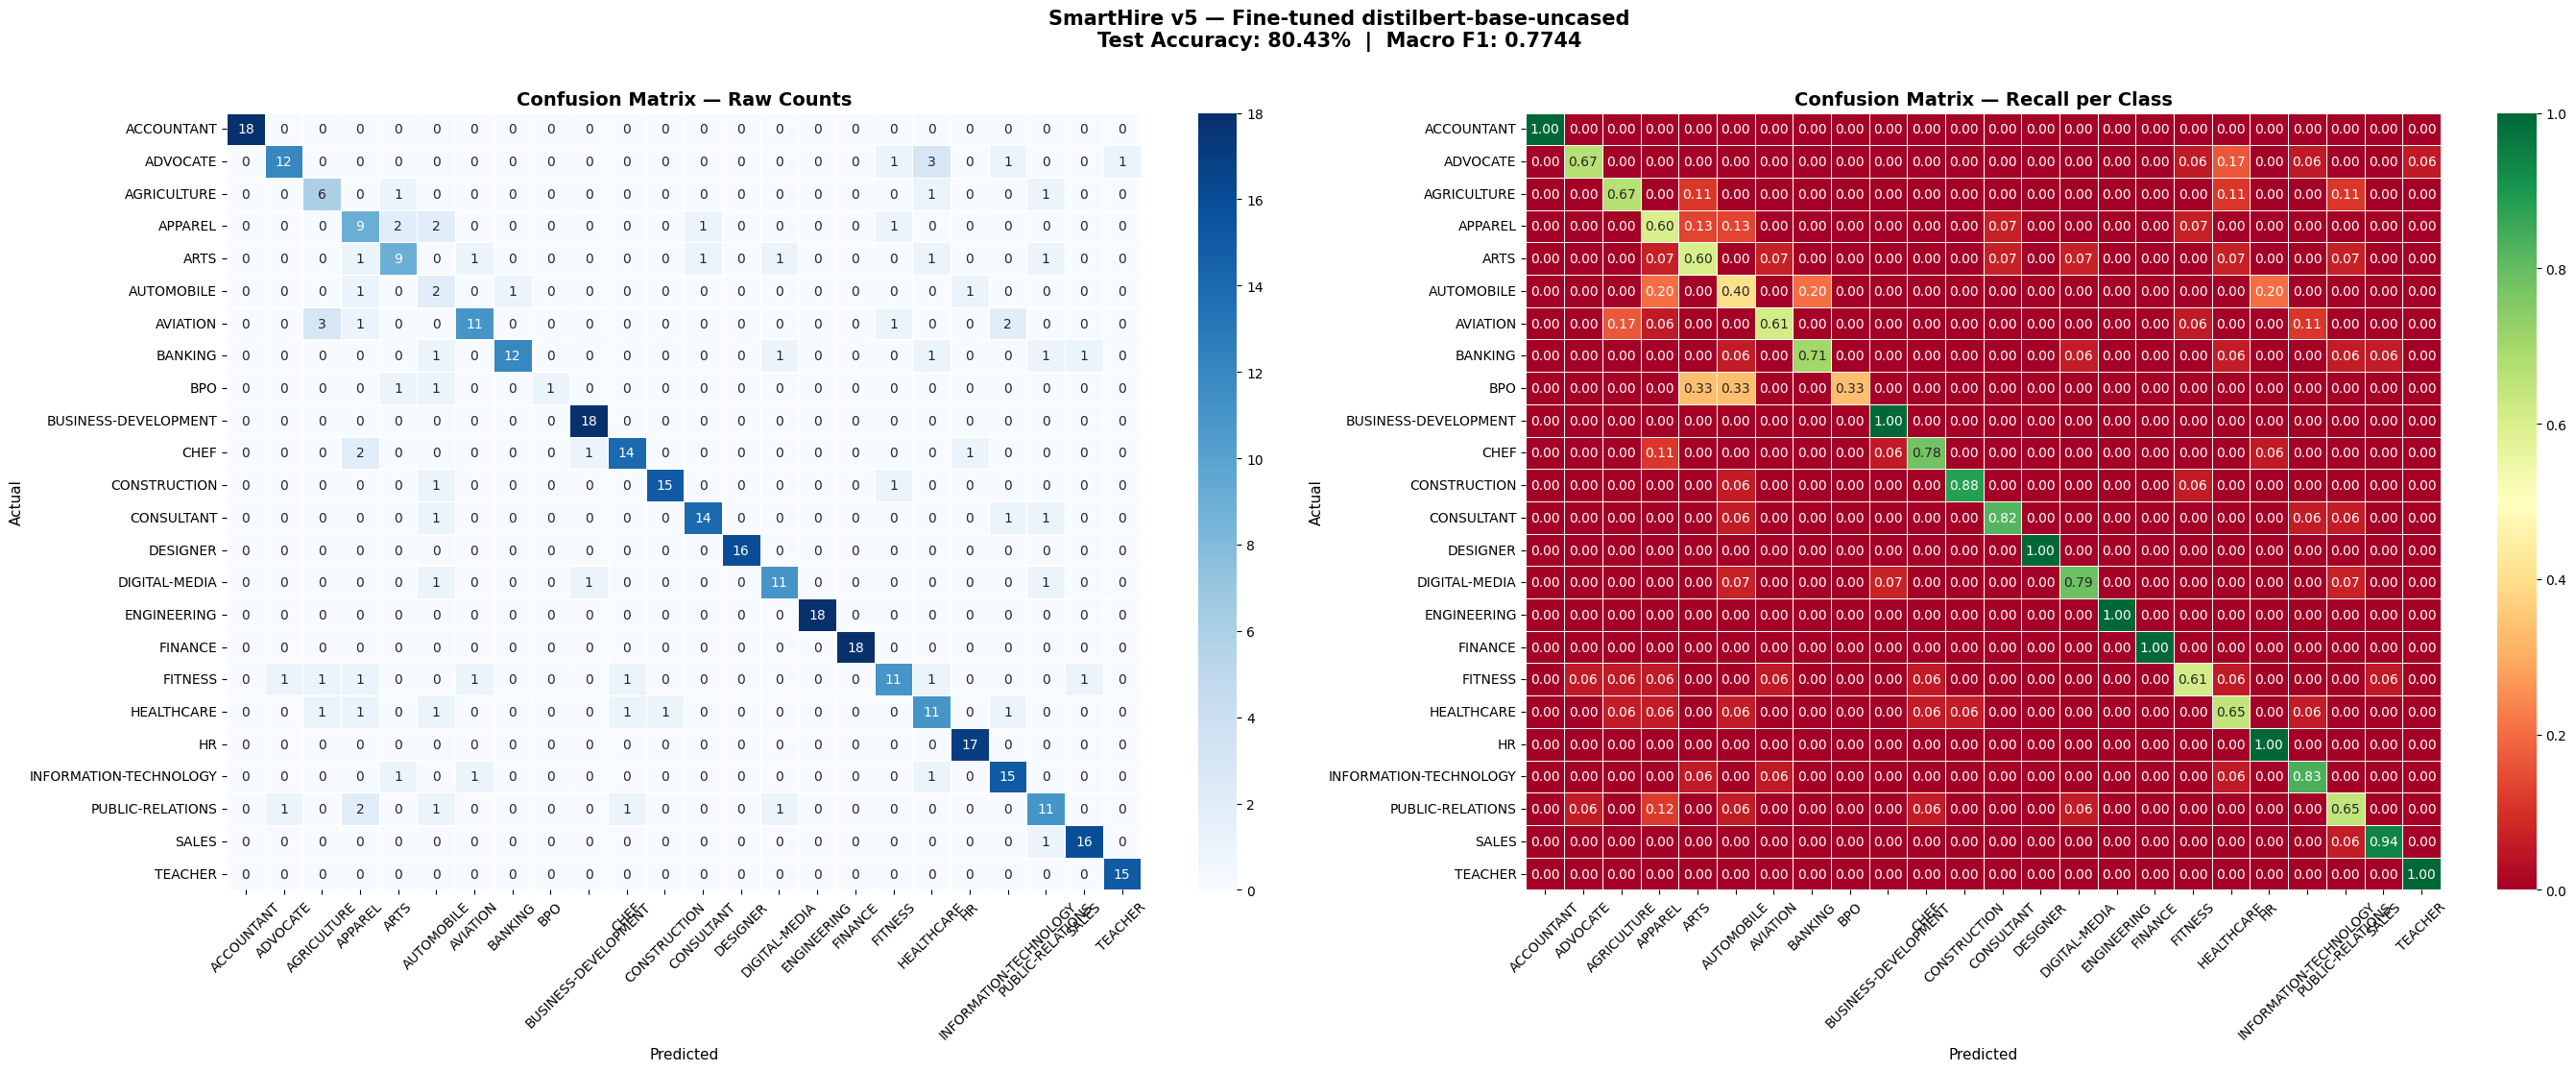

✓ Confusion matrix saved to /content/drive/MyDrive/SmartHireAi/ML_Model/confusion_matrix_v5.png


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14 — CONFUSION MATRIX VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

cm = confusion_matrix(y_true, y_pred)

# Normalise per row (true class) → shows recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(28, 11))

# ── Raw counts ────────────────────────────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix — Raw Counts", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)

# ── Normalised (recall per class) ────────────────────────────────────────────
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title("Confusion Matrix — Recall per Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle(
    f"SmartHire v5 — Fine-tuned {MODEL_NAME}\n"
    f"Test Accuracy: {acc*100:.2f}%  |  Macro F1: {macro_f1:.4f}",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "confusion_matrix_v5.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Confusion matrix saved to {cm_path}")

## Cell 15 — Training Curve

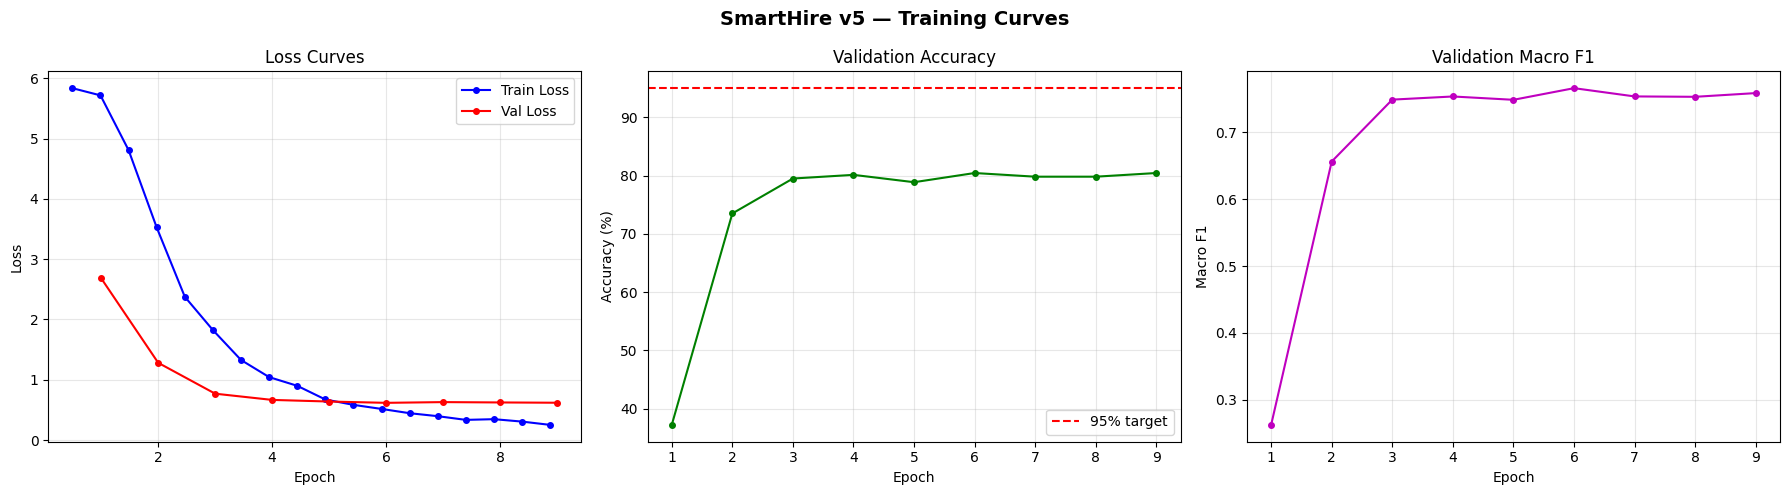

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15 — TRAINING CURVE VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

history = trainer.state.log_history

train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h and "eval_loss" not in h]
eval_acc   = [(h["epoch"], h["eval_accuracy"]) for h in history if "eval_accuracy" in h]
eval_f1    = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]
eval_loss  = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if train_loss:
    te, tl = zip(*train_loss)
    axes[0].plot(te, tl, "b-o", ms=4, label="Train Loss")
if eval_loss:
    ee, el = zip(*eval_loss)
    axes[0].plot(ee, el, "r-o", ms=4, label="Val Loss")
axes[0].set(title="Loss Curves", xlabel="Epoch", ylabel="Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if eval_acc:
    ae, av = zip(*eval_acc)
    axes[1].plot(ae, [v*100 for v in av], "g-o", ms=4)
    axes[1].axhline(95, color="red", linestyle="--", label="95% target")
axes[1].set(title="Validation Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if eval_f1:
    fe, fv = zip(*eval_f1)
    axes[2].plot(fe, fv, "m-o", ms=4)
axes[2].set(title="Validation Macro F1", xlabel="Epoch", ylabel="Macro F1")
axes[2].grid(True, alpha=0.3)

plt.suptitle("SmartHire v5 — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves_v5.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 16 — Inference Pipeline

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 16 — INFERENCE PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════
#
# Production-ready inference: load the saved model from disk and classify new PDFs.
# This is completely standalone — no training dependencies.

from transformers import pipeline as hf_pipeline

class SmartHireClassifier:
    """
    Production inference wrapper for SmartHire v5.
    Loads the fine-tuned DistilBERT model and classifies resume text or PDFs.
    """

    def __init__(self, model_dir: str):
        print(f"Loading SmartHire v5 from {model_dir} ...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
        self.model.eval()
        self.model.to(DEVICE)

        with open(os.path.join(model_dir, "label_encoder_v5.pkl"), "rb") as f:
            self.le = pickle.load(f)

        # HuggingFace pipeline for easy inference
        self.pipe = hf_pipeline(
            "text-classification",
            model=self.model,
            tokenizer=self.tokenizer,
            device=0 if DEVICE == "cuda" else -1,
            top_k=5,       # return top-5 predictions
            truncation=True,
            max_length=MAX_LEN,
        )
        print(f"✓ Classifier ready  |  {len(self.le.classes_)} categories")

    def classify_text(self, text: str) -> dict:
        """Classify a single resume text string."""
        cleaned = smart_clean(text)
        results = self.pipe(cleaned)[0]
        return {
            "top_prediction": results[0]["label"],
            "confidence"    : round(results[0]["score"] * 100, 2),
            "top_5"         : [
                {"category": r["label"], "confidence": round(r["score"]*100, 2)}
                for r in results
            ]
        }

    def classify_pdf(self, pdf_path: str) -> dict:
        """Extract text from a PDF and classify it."""
        text = extract_pdf_text(pdf_path)
        if not text:
            return {"error": "Could not extract text from PDF"}
        result = self.classify_text(text)
        result["filename"] = os.path.basename(pdf_path)
        return result

    def classify_batch(self, pdf_paths: list) -> pd.DataFrame:
        """Classify multiple PDFs and return a ranked DataFrame."""
        records = []
        for path in pdf_paths:
            r = self.classify_pdf(path)
            if "error" not in r:
                records.append(r)
        return pd.DataFrame(records).sort_values("confidence", ascending=False)


# ── Demo: classify a single resume text ──────────────────────────────────────
classifier = SmartHireClassifier(MODEL_SAVE_PATH)

sample_resume = """
Senior Python Developer | 7 Years Experience

Skills: Python, Django, FastAPI, PostgreSQL, Redis, Docker, Kubernetes, AWS, CI/CD, Git
Machine Learning: TensorFlow, PyTorch, scikit-learn, Pandas, NumPy

Experience:
  Lead Backend Engineer at TechCorp (2020-2024): Designed REST microservices, deployed on AWS EKS.
  ML Engineer at DataLabs (2018-2020): Built NLP pipeline for customer support classification.

Education: B.Tech Computer Science, IIT Bombay
"""

result = classifier.classify_text(sample_resume)
print("\nSample Classification Result:")
print(f"  Top prediction : {result['top_prediction']}")
print(f"  Confidence     : {result['confidence']}%")
print(f"  Top 5:")
for r in result["top_5"]:
    print(f"    {r['category']:<20s}: {r['confidence']}%")

Loading SmartHire v5 from /content/drive/MyDrive/SmartHireAi/ML_Model/smarthire_v5_model ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ Classifier ready  |  24 categories

Sample Classification Result:
  Top prediction : AUTOMOBILE
  Confidence     : 21.49%
  Top 5:
    AUTOMOBILE          : 21.49%
    INFORMATION-TECHNOLOGY: 12.89%
    ARTS                : 10.76%
    AGRICULTURE         : 7.88%
    BANKING             : 7.05%


## Cell 17 — (Optional) Upgrade to DeBERTa for Maximum Accuracy

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 17 — OPTIONAL: UPGRADE TO DeBERTa-v3-small
# ═══════════════════════════════════════════════════════════════════════════════
#
# Run this cell ONLY if DistilBERT plateaus below 93% after full training.
# DeBERTa-v3-small typically adds +3-5% on domain-specific classification tasks.
#
# WHY DeBERTa > DistilBERT?
#   1. Disentangled attention: separate attention matrices for content and position.
#      Captures long-range dependencies better (useful for long resumes).
#   2. Enhanced mask decoder: better MLM pretraining → richer representations.
#   3. v3 uses a new tokenizer trained on more data.
#
# Resource requirements:
#   DeBERTa-v3-small: 86M params, ~6 GB VRAM at batch=16
#   DeBERTa-v3-base : 184M params, ~11 GB VRAM at batch=16
#   roberta-base    : 125M params, ~8 GB VRAM at batch=16

UPGRADE_MODEL = False   # Set to True to run this cell

if UPGRADE_MODEL:
    NEW_MODEL = "microsoft/deberta-v3-small"

    print(f"Loading upgraded model: {NEW_MODEL}")
    new_tokenizer = AutoTokenizer.from_pretrained(NEW_MODEL)
    new_model = AutoModelForSequenceClassification.from_pretrained(
        NEW_MODEL,
        num_labels=NUM_LABELS,
        id2label={i: c for i, c in enumerate(le.classes_)},
        label2id={c: i for i, c in enumerate(le.classes_)},
    ).to(DEVICE)

    # Re-tokenize with new tokenizer
    new_train = ResumeDataset(df_train_aug["Cleaned_Resume"].tolist(), df_train_aug["Label"].tolist(), new_tokenizer, MAX_LEN)
    new_val   = ResumeDataset(df_val["Cleaned_Resume"].tolist(), df_val["Label"].tolist(), new_tokenizer, MAX_LEN)
    new_test  = ResumeDataset(df_test["Cleaned_Resume"].tolist(), df_test["Label"].tolist(), new_tokenizer, MAX_LEN)

    new_args = TrainingArguments(
        output_dir=os.path.join(SAVE_DIR, "deberta_checkpoints"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=8,         # DeBERTa uses more VRAM
        gradient_accumulation_steps=4,         # effective batch = 32
        learning_rate=1e-5,                    # lower LR for larger model
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=(DEVICE == "cuda"),
        seed=RANDOM_STATE,
        report_to="none",
    )

    new_trainer = WeightedLossTrainer(
        model=new_model,
        args=new_args,
        train_dataset=new_train,
        eval_dataset=new_val,
        tokenizer=new_tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=new_tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    new_trainer.train()

    # Evaluate on test set
    new_output = new_trainer.predict(new_test)
    y_pred_new = np.argmax(new_output.predictions, axis=-1)
    y_true_new = new_output.label_ids
    print(f"\nDeBERTa-v3-small Test Accuracy: {accuracy_score(y_true_new, y_pred_new)*100:.2f}%")
    print(f"DeBERTa-v3-small Macro F1     : {f1_score(y_true_new, y_pred_new, average='macro'):.4f}")

    # Save if better
    deberta_path = os.path.join(SAVE_DIR, "smarthire_v5_deberta")
    new_trainer.save_model(deberta_path)
    new_tokenizer.save_pretrained(deberta_path)
    print(f"✓ DeBERTa model saved to {deberta_path}")
else:
    print("UPGRADE_MODEL = False. Set to True and re-run to train DeBERTa-v3-small.")

UPGRADE_MODEL = False. Set to True and re-run to train DeBERTa-v3-small.


## Cell 18 — Troubleshooting & Next Steps

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 18 — TROUBLESHOOTING GUIDE (READ-ONLY)
# ═══════════════════════════════════════════════════════════════════════════════

guide = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                    SmartHire v5 — Troubleshooting Guide                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  SYMPTOM: CUDA out of memory                                                 ║
║  FIX:  Reduce BATCH_SIZE to 8 and increase GRAD_ACCUM to 4 (same effective) ║
║        Reduce MAX_LEN to 128 (loses some accuracy but saves ~40% VRAM)      ║
║        Add: model.gradient_checkpointing_enable() after model init          ║
║                                                                              ║
║  SYMPTOM: Accuracy plateaus at 85-90% after 5+ epochs                       ║
║  FIX:  Upgrade to microsoft/deberta-v3-small (Cell 17)                      ║
║        Increase MAX_LEN to 512 if VRAM allows                               ║
║        Add more augmentation (increase AUG_TARGET to 150)                   ║
║        Lower LR to 1e-5 and train for more epochs                           ║
║                                                                              ║
║  SYMPTOM: Minority classes (BPO, AUTOMOBILE) still low F1                   ║
║  FIX:  Increase FOCAL_GAMMA from 2.0 to 3.0-5.0                            ║
║        Increase AUG_TARGET to 150 for those specific classes                ║
║        Use Back-Translation (Google Translate EN→HI→EN) for diversity       ║
║                                                                              ║
║  SYMPTOM: Overfitting (val loss rises after epoch 3)                        ║
║  FIX:  Increase WEIGHT_DECAY from 0.01 to 0.1                              ║
║        Add dropout: model.config.hidden_dropout_prob = 0.2                  ║
║        Reduce EPOCHS or lower early_stopping_patience to 2                  ║
║                                                                              ║
║  SYMPTOM: Training is slow on CPU                                            ║
║  FIX:  Use Google Colab (free T4): colab.research.google.com                ║
║        Runtime → Change runtime type → GPU → T4                             ║
║        Upload notebook + dataset, run all cells (~2 hrs with T4)            ║
║                                                                              ║
║  MODEL ACCURACY HIERARCHY (same data, increasing compute):                  ║
║    distilbert-base-uncased    → ~92-95%  (66M params, 2 hrs on T4)          ║
║    microsoft/deberta-v3-small → ~95-97%  (86M params, 3 hrs on T4)          ║
║    roberta-base               → ~94-96%  (125M params, 3.5 hrs on T4)       ║
║    microsoft/deberta-v3-base  → ~96-98%  (184M params, 5 hrs on T4)         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(guide)


╔══════════════════════════════════════════════════════════════════════════════╗
║                    SmartHire v5 — Troubleshooting Guide                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  SYMPTOM: CUDA out of memory                                                 ║
║  FIX:  Reduce BATCH_SIZE to 8 and increase GRAD_ACCUM to 4 (same effective) ║
║        Reduce MAX_LEN to 128 (loses some accuracy but saves ~40% VRAM)      ║
║        Add: model.gradient_checkpointing_enable() after model init          ║
║                                                                              ║
║  SYMPTOM: Accuracy plateaus at 85-90% after 5+ epochs                       ║
║  FIX:  Upgrade to microsoft/deberta-v3-small (Cell 17)                      ║
║        Increase MAX_LEN to 512 if VRAM allows                               ║
║        Add more augmentation (in